# Repo Census Visualization

## Setup

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

file_path = Path("..", "..", "data", "processed", "repo-census.csv")

df = pd.read_csv(file_path)

num_cols = [
    "n_files_total", "n_files_py", "loc_total_all_text", "loc_total_py",
    "n_files_py_tests", "loc_py_tests", "n_files_py_vendor", "loc_py_vendor",
    "n_files_py_docs", "loc_py_docs",
    "n_files_encoding_error", "n_files_binary"
]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

## Comparison of code between old and new projects

,group,repos,total_py_files,total_py_loc,total_test_files,total_test_loc
0,new_2020s,8,2119,252785,939,88366
1,old_2000s,8,1919,332997,1181,120638


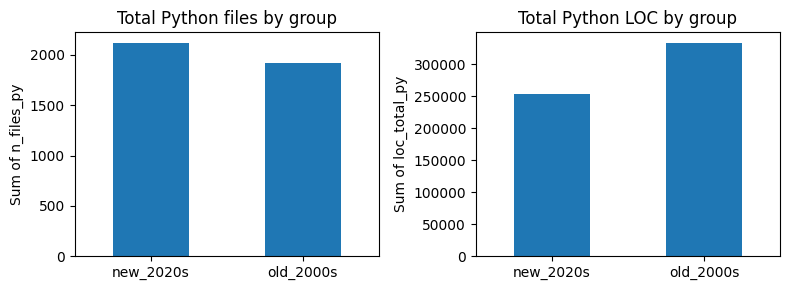

In [37]:
group_summary = (
    df.groupby("group", as_index=False)
      .agg(
          repos=("name", "count"),
          total_py_files=("n_files_py", "sum"),
          total_py_loc=("loc_total_py", "sum"),
          total_test_files=("n_files_py_tests", "sum"),
          total_test_loc=("loc_py_tests", "sum"),
      )
)

display(group_summary)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# Chart 1
group_summary.plot(
    kind="bar",
    x="group",
    y="total_py_files",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Total Python files by group")
axes[0].set_xlabel("")
axes[0].set_ylabel("Sum of n_files_py")
axes[0].tick_params(axis="x", rotation=0)

# Chart 2
group_summary.plot(
    kind="bar",
    x="group",
    y="total_py_loc",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Total Python LOC by group")
axes[1].set_xlabel("")
axes[1].set_ylabel("Sum of loc_total_py")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [38]:
old_repos = (
    df[df["group"] == "old_2000s"]
      .sort_values("n_files_py")
      [["name", "n_files_py"]]
)
new_repos = (
    df[df["group"] == "new_2020s"]
      .sort_values("n_files_py")
      [["name", "n_files_py"]]
)

combined = pd.concat(
    [
        old_repos.reset_index(drop=True),
        new_repos.reset_index(drop=True)
    ],
    axis=1
)

display(combined)

,name,n_files_py,name,n_files_py
0,virtualenv,8,poetry-plugin-export,19
1,coverage,17,build,33
2,setuptools,40,pip-audit,53
3,pip,59,pytask,65
4,pygments,86,rich,190
5,nose,244,pdm,221
6,ipython,321,typer,598
7,scons,1144,textualize,940


## Python testing, vendor and docs density

,name,test_loc_share,name,vendor_loc_share,name,docs_loc_share
0,poetry-plugin-export,0.848963,ipython,0.111369,typer,0.197821
1,typer,0.571105,pygments,0.010802,textualize,0.074422
2,build,0.567171,pip,0.000000,nose,0.064635
3,scons,0.542732,virtualenv,0.000000,ipython,0.052634
4,pip-audit,0.485791,setuptools,0.000000,pygments,0.019663
5,nose,0.345429,scons,0.000000,build,0.018448
6,pdm,0.337468,coverage,0.000000,pip,0.017080
7,textualize,0.333113,nose,0.000000,rich,0.002075
8,pip,0.269948,pip-audit,0.000000,virtualenv,0.000000
9,rich,0.269107,typer,0.000000,setuptools,0.000000


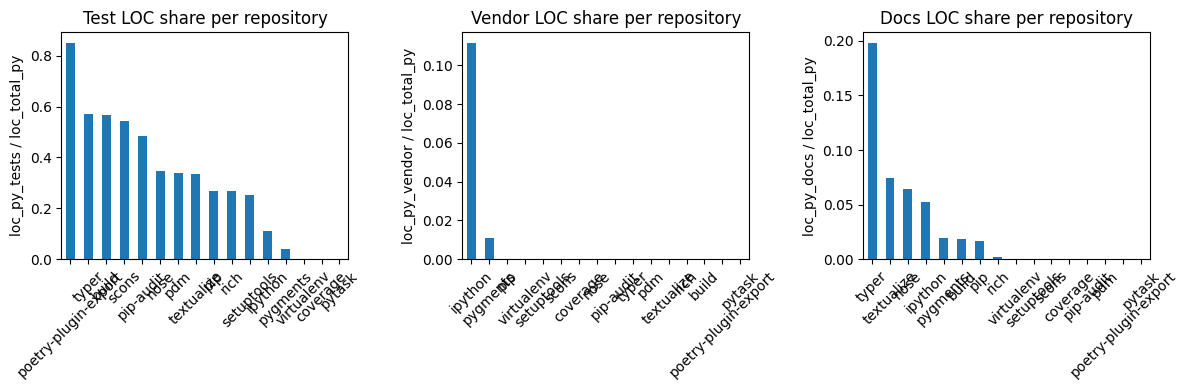

In [39]:
df["test_loc_share"] = df["loc_py_tests"] / df["loc_total_py"]
df["vendor_loc_share"] = df["loc_py_vendor"] / df["loc_total_py"]
df["docs_loc_share"] = df["loc_py_docs"] / df["loc_total_py"]

repo_share = (
    df[["name", "test_loc_share"]]
    .sort_values("test_loc_share", ascending=False)
)

repo_share_vendor = (
    df[["name", "vendor_loc_share"]]
    .sort_values("vendor_loc_share", ascending=False)
)

repo_share_docs = (
    df[["name", "docs_loc_share"]]
    .sort_values("docs_loc_share", ascending=False)
)

combined = pd.concat(
    [
        repo_share.reset_index(drop=True),
        repo_share_vendor.reset_index(drop=True),
        repo_share_docs.reset_index(drop=True)
    ],
    axis=1
)

display(combined)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

repo_share.plot(
    kind="bar",
    x="name",
    y="test_loc_share",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Test LOC share per repository")
axes[0].set_xlabel("")
axes[0].set_ylabel("loc_py_tests / loc_total_py")
axes[0].tick_params(axis="x", rotation=45)

repo_share_vendor.plot(
    kind="bar",
    x="name",
    y="vendor_loc_share",
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Vendor LOC share per repository")
axes[1].set_xlabel("")
axes[1].set_ylabel("loc_py_vendor / loc_total_py")
axes[1].tick_params(axis="x", rotation=45)

repo_share_docs.plot(
    kind="bar",
    x="name",
    y="docs_loc_share",
    legend=False,
    ax=axes[2]
)

axes[2].set_title("Docs LOC share per repository")
axes[2].set_xlabel("")
axes[2].set_ylabel("loc_py_docs / loc_total_py")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Python files and loc per repo excluding tests, vendors and docs

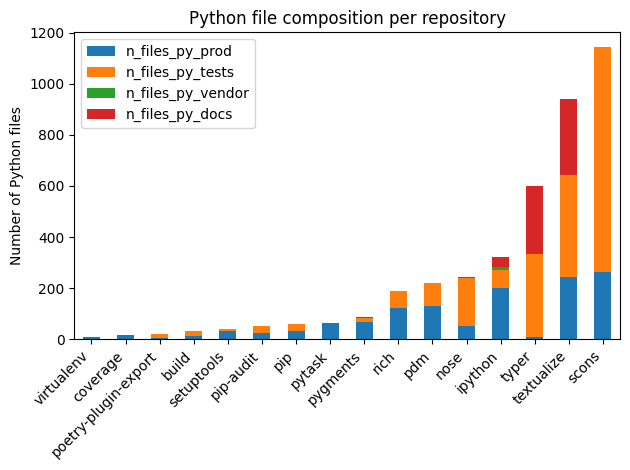

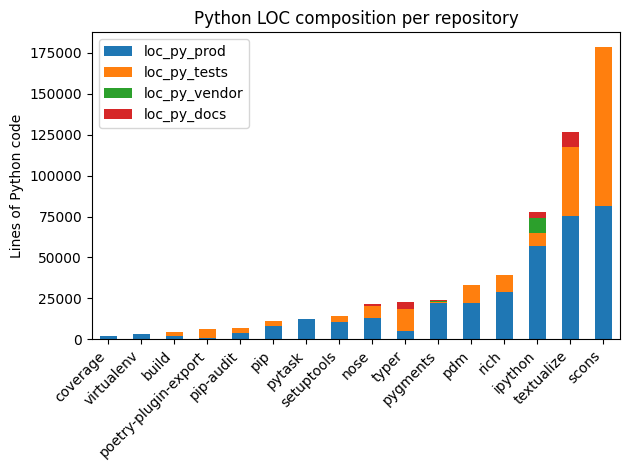

In [40]:
df["n_files_py_prod"] = (
    df["n_files_py"]
    - df["n_files_py_tests"]
    - df["n_files_py_vendor"]
    - df["n_files_py_docs"]
).clip(lower=0)

df["loc_py_prod"] = (
    df["loc_total_py"]
    - df["loc_py_tests"]
    - df["loc_py_vendor"]
    - df["loc_py_docs"]
).clip(lower=0)

repo_files = df.sort_values("n_files_py")

repo_files.set_index("name")[[
    "n_files_py_prod",
    "n_files_py_tests",
    "n_files_py_vendor",
    "n_files_py_docs"
]].plot(kind="bar", stacked=True)

plt.title("Python file composition per repository")
plt.ylabel("Number of Python files")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

repo_loc = df.sort_values("loc_total_py")

repo_loc.set_index("name")[[
    "loc_py_prod",
    "loc_py_tests",
    "loc_py_vendor",
    "loc_py_docs"
]].plot(kind="bar", stacked=True)

plt.title("Python LOC composition per repository")
plt.ylabel("Lines of Python code")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [41]:
old_repos = (
    df[df["group"] == "old_2000s"]
      .sort_values("n_files_py_prod")
      [["name", "n_files_py_prod"]]
)
new_repos = (
    df[df["group"] == "new_2020s"]
      .sort_values("n_files_py_prod")
      [["name", "n_files_py_prod"]]
)

combined = pd.concat(
    [
        old_repos.reset_index(drop=True),
        new_repos.reset_index(drop=True)
    ],
    axis=1
)

display(combined)

,name,n_files_py_prod,name,n_files_py_prod
0,virtualenv,8,poetry-plugin-export,5
1,coverage,17,typer,8
2,pip,33,build,13
3,setuptools,34,pip-audit,26
4,nose,53,pytask,65
5,pygments,69,rich,123
6,ipython,202,pdm,130
7,scons,265,textualize,245


In [42]:
old_repos = (
    df[df["group"] == "old_2000s"]
      .sort_values("loc_py_prod")
      [["name", "loc_py_prod"]]
)
new_repos = (
    df[df["group"] == "new_2020s"]
      .sort_values("loc_py_prod")
      [["name", "loc_py_prod"]]
)

combined = pd.concat(
    [
        old_repos.reset_index(drop=True),
        new_repos.reset_index(drop=True)
    ],
    axis=1
)

display(combined)

,name,loc_py_prod,name,loc_py_prod
0,coverage,2281,poetry-plugin-export,939
1,virtualenv,3027,build,1752
2,pip,8140,pip-audit,3637
3,setuptools,10643,typer,5302
4,nose,12778,pytask,12585
5,pygments,22005,pdm,22061
6,ipython,56696,rich,28808
7,scons,81675,textualize,75191


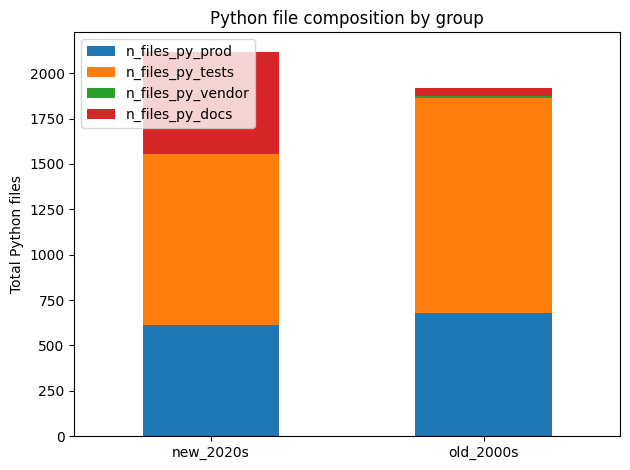

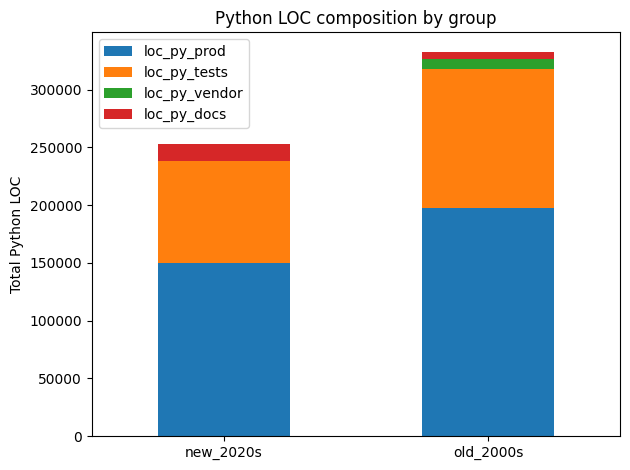

In [43]:
group_files = df.groupby("group")[[
    "n_files_py_prod",
    "n_files_py_tests",
    "n_files_py_vendor",
    "n_files_py_docs"
]].sum()

group_files.plot(kind="bar", stacked=True)

plt.title("Python file composition by group")
plt.ylabel("Total Python files")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

group_loc = df.groupby("group")[[
    "loc_py_prod",
    "loc_py_tests",
    "loc_py_vendor",
    "loc_py_docs"
]].sum()

group_loc.plot(kind="bar", stacked=True)

plt.title("Python LOC composition by group")
plt.ylabel("Total Python LOC")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

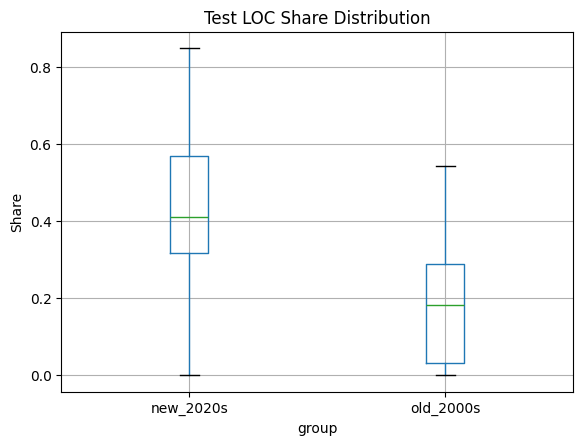

In [44]:
df["test_loc_share"] = df["loc_py_tests"] / df["loc_total_py"]

df.boxplot(column="test_loc_share", by="group")
plt.title("Test LOC Share Distribution")
plt.suptitle("")
plt.ylabel("Share")
plt.show()